In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# 1. Iniciar sesión limpia (sin paquetes externos conflictivos)
spark = SparkSession.builder.appName("GrafosNativos").getOrCreate()

# 2. Definir Vértices (Nodos de la red)
vertices = spark.createDataFrame([
  ("e1", "Ana", "Data Engineer"),
  ("e2", "Luis", "Data Scientist"),
  ("e3", "Marta", "CTO"),
  ("e4", "Carlos", "Analista")
], ["id", "nombre", "rol"])

# 3. Definir Aristas (Relaciones de la red)
aristas = spark.createDataFrame([
  ("e1", "e3", "reporta_a"),
  ("e2", "e3", "reporta_a"),
  ("e4", "e2", "reporta_a"),
  ("e1", "e2", "ayuda_a"),
  ("e4", "e1", "ayuda_a")
], ["src", "dst", "relacion"])

print("--- RED DE EMPLEADOS CREADA ---")


--- RED DE EMPLEADOS CREADA ---


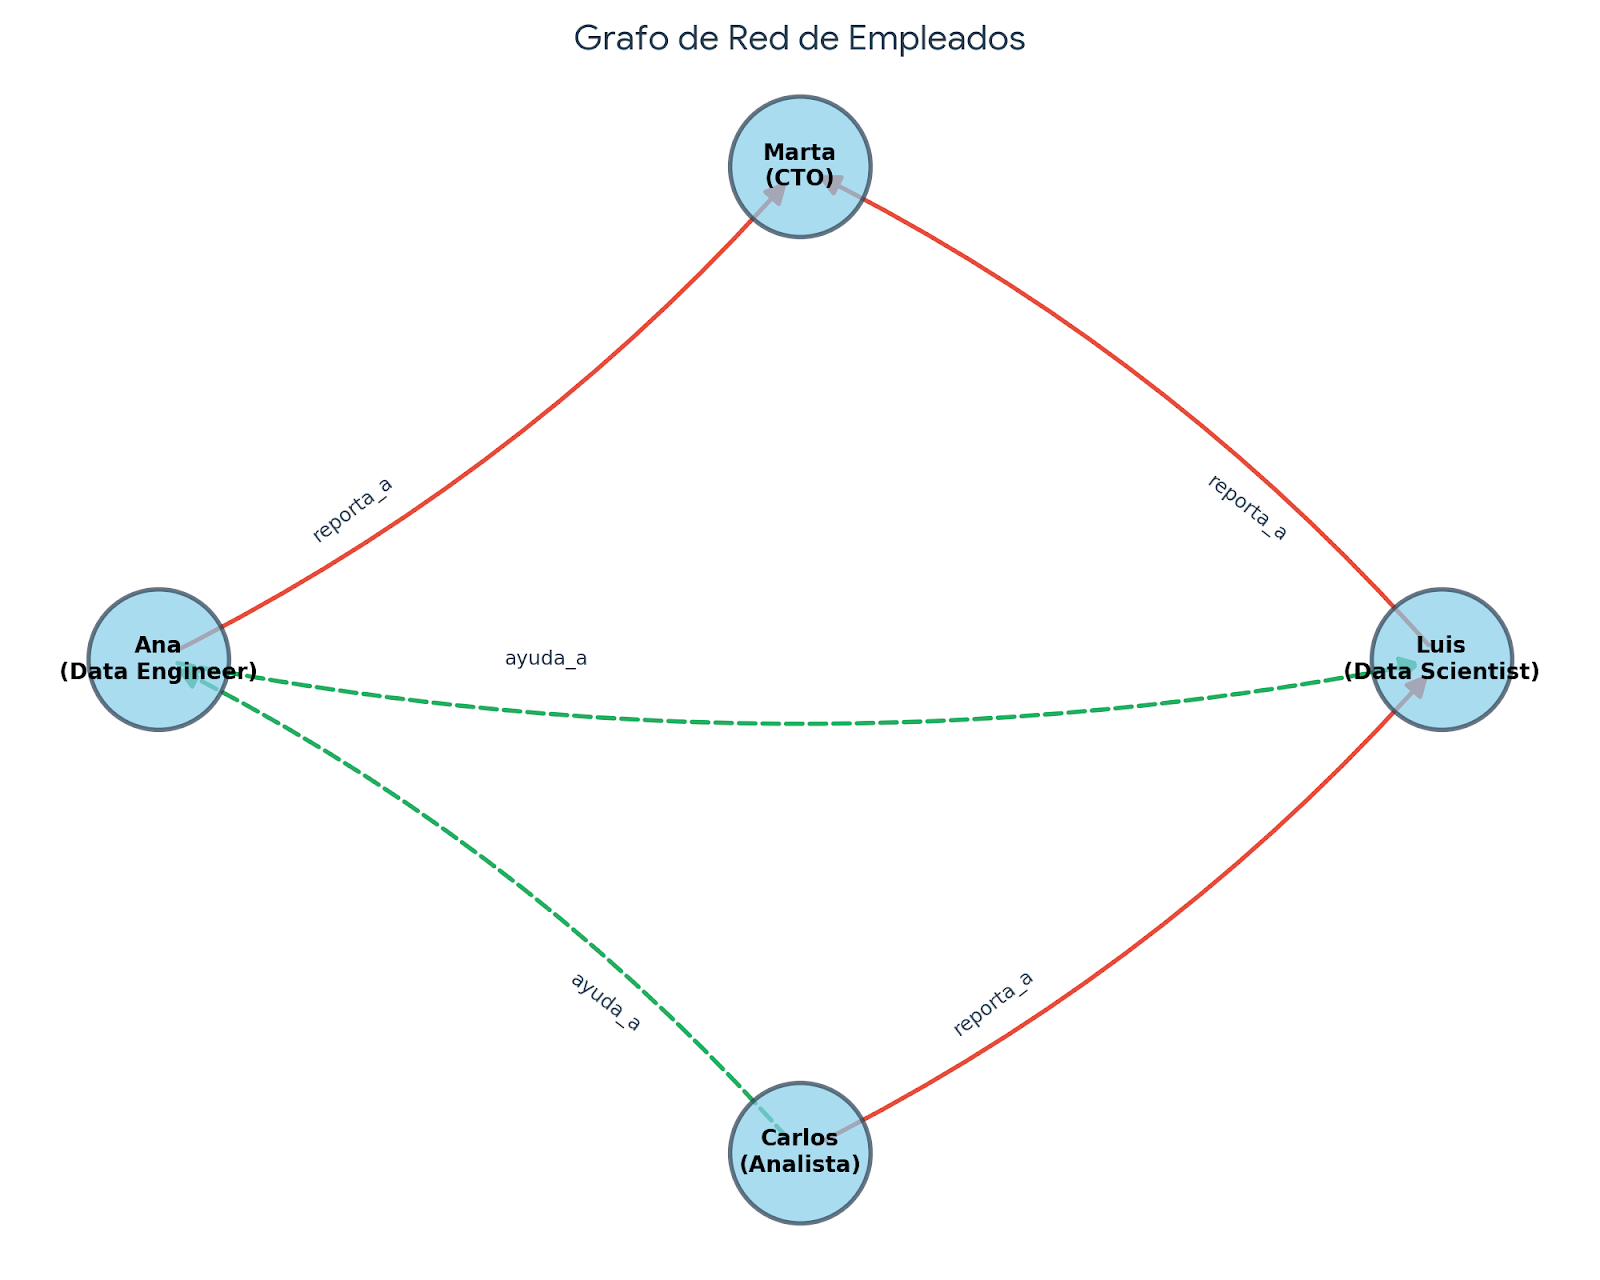

In [ ]:
# =====================================================================
# EJEMPLO 1: BÚSQUEDA DE PATRONES
# =====================================================================
# Objetivo: Encontrar el patrón (A) -> reporta a -> (B) -> reporta a -> (C)
# ¿Cómo se hace en un grafo? Con un Auto-Join de las aristas consigo mismas.

aristas_a_b = aristas.filter("relacion = 'reporta_a'").alias("ab")
aristas_b_c = aristas.filter("relacion = 'reporta_a'").alias("bc")

# Unimos donde el destino del primero es el origen del segundo
patron_jerarquia = aristas_a_b.join(
    aristas_b_c,
    col("ab.dst") == col("bc.src")
).select(
    col("ab.src").alias("id_empleado"),
    col("ab.dst").alias("id_jefe_intermedio"),
    col("bc.dst").alias("id_gran_jefe")
)

print("\n1. Patrón Jerárquico: ¿Quién reporta a alguien que a su vez reporta a otro?")
patron_jerarquia.show()


1. Patrón Jerárquico: ¿Quién reporta a alguien que a su vez reporta a otro?
+-----------+------------------+------------+
|id_empleado|id_jefe_intermedio|id_gran_jefe|
+-----------+------------------+------------+
|         e4|                e2|          e3|
+-----------+------------------+------------+



In [ ]:

# =====================================================================
# EJEMPLO 2: MÉTRICAS DEL GRAFO (In-Degrees)
# =====================================================================
# Objetivo: ¿Quién es el nodo central? (El que recibe más conexiones entrantes)
# ¿Cómo se hace? Agrupando por la columna destino (dst).

in_degrees = aristas.groupBy("dst").count().withColumnRenamed("count", "conexiones_entrantes")

# Cruzamos con los vértices para ver los nombres
nodos_importantes = in_degrees.join(
    vertices,
    col("dst") == col("id")
).select("nombre", "rol", "conexiones_entrantes").orderBy("conexiones_entrantes", ascending=False)

print("\n2. In-Degrees (Nodos más conectados/solicitados):")
nodos_importantes.show()


2. In-Degrees (Nodos más conectados/solicitados):
+------+--------------+--------------------+
|nombre|           rol|conexiones_entrantes|
+------+--------------+--------------------+
|  Luis|Data Scientist|                   2|
| Marta|           CTO|                   2|
|   Ana| Data Engineer|                   1|
+------+--------------+--------------------+

